In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torchvision.transforms as T

In [51]:
EMBED_SIZE = 512
HIDDEN_SIZE = 512
ATTENTION_DIM = 256
NUM_LAYERS = 1
BATCH_SIZE = 64
LR = 3e-4
EPOCHS = 3
MAX_SEQ_LEN = 20
MIN_WORD_FREQ = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [52]:
import torch
torch.cuda.empty_cache()

if encoder:
    del encoder

if decoder:
    del decoder

torch.cuda.empty_cache()

In [53]:
import os
import re
import json
import random
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

# For evaluation:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

In [54]:
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.18 GB


In [55]:
def collate_fn(batch):
    """
    Collate function for Flickr dataset.
    Sorts by caption length (descending) for packing.
    """
    # Unpack dataset outputs
    imgs, caps, lengths, names = zip(*batch)

    # Stack images
    imgs = torch.stack(imgs, 0)

    # Convert captions to tensor
    caps = torch.stack(caps, 0)

    # Lengths are already known
    lengths = torch.tensor(lengths)

    return imgs, caps, lengths, names

In [56]:
class Vocabulary:
    def __init__(self, freq_threshold=MIN_WORD_FREQ):
        self.freq_threshold = freq_threshold
        self.word2idx = {"<pad>":0, "<start>":1, "<end>":2, "<unk>":3}
        self.idx2word = {0:"<pad>", 1:"<start>", 2:"<end>", 3:"<unk>"}
        self.freqs = Counter()
        self.next_idx = 4

    def tokenize(self, text):
        text = text.lower()
        # simple tokenization; students can replace with better tokenizer
        tokens = re.findall(r"\w+", text)
        return tokens

    def build_vocab(self, captions_list):
        for caption in captions_list:
            tokens = self.tokenize(caption)
            self.freqs.update(tokens)
        for word, cnt in self.freqs.items():
            if cnt >= self.freq_threshold:
                self.word2idx[word] = self.next_idx
                self.idx2word[self.next_idx] = word
                self.next_idx += 1

    def numericalize(self, text):
        tokens = self.tokenize(text)
        return [self.word2idx.get(tok, self.word2idx["<unk>"]) for tok in tokens]

In [57]:
class FlickrDataset(Dataset):
    def __init__(self, images_dir, captions_file, vocab, transform=None, max_len=50):
        self.images_dir = images_dir
        self.vocab = vocab
        self.transform = transform
        self.max_len = max_len
        
        # Dictionary to store all captions for each image
        self.img_caps = {}

        with open(captions_file, 'r') as f:
            lines = [l.strip() for l in f.readlines() if len(l.strip()) > 0]

        # Handle CSV or TSV formats
        if ',' in lines[0] and '\t' not in lines[0]:
            if 'image' in lines[0].lower():  # skip header
                lines = lines[1:]
            self.data = []
            for line in lines:
                if ',' in line:
                    parts = line.split(',', 1)
                    if len(parts) == 2:
                        img_name, caption = parts
                        self.data.append((img_name, caption))
                        # Store caption for this image
                        if img_name not in self.img_caps:
                            self.img_caps[img_name] = []
                        self.img_caps[img_name].append(caption)
        else:
            self.data = []
            for line in lines:
                if '\t' in line:
                    img, cap = line.split('\t')
                    img_name = img.split('#')[0]
                    self.data.append((img_name, cap))
                    # Store caption for this image
                    if img_name not in self.img_caps:
                        self.img_caps[img_name] = []
                    self.img_caps[img_name].append(cap)

        print(f"✅ Parsed {len(self.data)} image-caption pairs")
        print(f"✅ Found {len(self.img_caps)} unique images")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name, caption = self.data[idx]
        img_path = os.path.join(self.images_dir, img_name)

        # Load image
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Tokenize caption
        tokens = [self.vocab.word2idx.get("<start>")] + [
            self.vocab.word2idx.get(word.lower(), self.vocab.word2idx["<unk>"]) 
            for word in caption.split()
        ] + [self.vocab.word2idx.get("<end>")]

        # Pad sequence
        if len(tokens) < self.max_len:
            tokens += [self.vocab.word2idx["<pad>"]] * (self.max_len - len(tokens))
        else:
            tokens = tokens[:self.max_len]

        return image, torch.tensor(tokens), len(tokens), img_name

In [58]:
IMAGES_DIR = "Flicker8k_Dataset"
CAPTIONS_FILE = "captions.txt"

In [59]:
print("Building vocabulary...")
caps = []
with open(CAPTIONS_FILE, 'r', encoding='utf-8') as f:
    lines = f.readlines()
    if 'image' in lines[0].lower():  # Skip CSV header
        lines = lines[1:]
    for line in lines:
        line = line.strip()
        if not line: 
            continue
        if ',' in line:
            parts = line.split(',', 1)
            if len(parts) == 2:
                caps.append(parts[1])

vocab = Vocabulary(freq_threshold=MIN_WORD_FREQ)
vocab.build_vocab(caps)
print(f"Vocab size: {len(vocab.word2idx)}")

Building vocabulary...
Vocab size: 2982


#Question (10 marks total). You have the boilerplate image-captioning code from previous lab. Perform the tasks below and submit: (i) modified code files or diff, results and answers. Label your answers (a)–(d).

#(a) Implement soft attention and show alpha sums = 1 for a batch. (5 marks)
Paper: Show, Attend and Tell (Xu et al., 2015)[https://arxiv.org/pdf/1502.03044]
Perform training and evaluation separately as per previous lab.

#(b) Visualize attention maps for 5 test images and comment. (5 marks)

---
#### Q(a) Revised implementations of lab 8 for attention
#### primarily focused on extracting spatial features and the modifications involved

In [60]:
class AttentionEncoder(nn.Module):
    """
    CNN encoder that outputs spatial features for attention, modified from lab 8 code.
    """
    def __init__(self, embed_size=EMBED_SIZE):
        super().__init__()
        import torchvision.models as models
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        
        for param in resnet.parameters():
            param.requires_grad = False
        
        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))
        self.projector = nn.Conv2d(2048, embed_size, kernel_size=1)
        
    def forward(self, images):
        with torch.no_grad():
            features = self.resnet(images)
        
        features = self.adaptive_pool(features)
        features = self.projector(features)
        
        B, C, H, W = features.shape
        features = features.view(B, C, H * W)
        features = features.permute(0, 2, 1) 
        
        return features

In [61]:
class SoftAttention(nn.Module):
    """
    Soft attention mechanism from the paper as instructed in assignment.
    """
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        
    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)

        att2 = self.decoder_att(decoder_hidden)
        att2 = att2.unsqueeze(1)

        att = self.full_att(torch.tanh(att1 + att2))
        att = att.squeeze(2)

        alpha = F.softmax(att, dim=1)

        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        
        return alpha, context

In [62]:
class DecoderWithAttention(nn.Module):
    """
    LSTM decoder with soft attention mechanism modified form lab 8 code.
    """
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim, encoder_dim=512):
        super().__init__()
        self.embed_size = embed_size
        self.hidden_size = hidden_size
        self.vocab_size = vocab_size
        self.encoder_dim = encoder_dim
        
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.attention = SoftAttention(encoder_dim, hidden_size, attention_dim)

        self.lstm_cell = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)

        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)
        
    def _init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = torch.tanh(self.init_h(mean_encoder_out))
        c = torch.tanh(self.init_c(mean_encoder_out))
        return h, c
    
    def forward(self, encoder_out, captions, lengths):
        batch_size = encoder_out.size(0)
        num_pixels = encoder_out.size(1)

        h, c = self._init_hidden_state(encoder_out)
        embeddings = self.embedding(captions)

        predictions = []
        alphas = []
        
        for t in range(captions.size(1)):
            alpha, context = self.attention(encoder_out, h)
            alphas.append(alpha.unsqueeze(1))

            lstm_input = torch.cat([embeddings[:, t, :], context], dim=1)
            h, c = self.lstm_cell(lstm_input, (h, c))

            output = self.fc(self.dropout(h))
            predictions.append(output.unsqueeze(1))

        predictions = torch.cat(predictions, dim=1)
        alphas = torch.cat(alphas, dim=1)
        
        return predictions, alphas
    
    def sample(self, encoder_out, vocab, max_len=20):
        self.eval()
        with torch.no_grad():
            batch_size = encoder_out.size(0)
            h, c = self._init_hidden_state(encoder_out)

            inputs = torch.tensor([vocab.word2idx["<start>"]] * batch_size,
                                 device=encoder_out.device)
            
            captions = []
            alphas_list = []
            
            for _ in range(max_len):
                alpha, context = self.attention(encoder_out, h)
                alphas_list.append(alpha.unsqueeze(1))

                embeddings = self.embedding(inputs)

                lstm_input = torch.cat([embeddings, context], dim=1)
                h, c = self.lstm_cell(lstm_input, (h, c))

                output = self.fc(h)
                predicted = output.argmax(dim=1)
                
                captions.append(predicted.unsqueeze(1))
                inputs = predicted
            
            captions = torch.cat(captions, dim=1)
            alphas = torch.cat(alphas_list, dim=1)
            
        return captions, alphas

verifying alpha sums upto 1

In [63]:
def verify_attention_weights(encoder, decoder, dataloader, vocab):
    """
    Verify that attention weights alpha sum to 1 for a batch
    """
    encoder.eval()
    decoder.eval()
    
    # Get one batch
    imgs, caps, lengths, names = next(iter(dataloader))
    imgs = imgs.to(DEVICE)
    caps = caps.to(DEVICE)
    
    with torch.no_grad():
        encoder_out = encoder(imgs)
        predictions, alphas = decoder(encoder_out, caps[:, :-1], lengths)

    alpha_sums = alphas.sum(dim=2)  # (B, max_len)
    
    print("\nFirst 5 samples, first 5 timesteps:")
    print(alpha_sums[:5, :5].cpu().numpy())

In [64]:
def train_with_attention(images_dir, captions_txt, vocab, encoder, decoder, 
                        save_name='attention_model.pth', epochs=EPOCHS):
    """
    Training loop for attention-based model modfied from lab 8 code.
    """
    from torch.utils.data import DataLoader
    from tqdm import tqdm
    import time
    
    print(f"Vocab size: {len(vocab.word2idx)}")
    
    transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    dataset = FlickrDataset(images_dir, captions_txt, vocab, 
                           transform=transform, max_len=MAX_SEQ_LEN)
    
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, 
                           collate_fn=collate_fn, num_workers=4, 
                           pin_memory=True, persistent_workers=True)
    
    criterion = nn.CrossEntropyLoss(ignore_index=vocab.word2idx["<pad>"])

    optimizer = optim.AdamW(decoder.parameters(), lr=LR, weight_decay=1e-4)

    scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
    
    start_time = time.time()
    
    for epoch in range(epochs):
        encoder.eval()
        decoder.train()
        
        total_loss = 0
        epoch_start = time.time()
        
        for imgs, caps, lengths, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs = imgs.to(DEVICE, non_blocking=True)
            caps = caps.to(DEVICE, non_blocking=True)
            
            optimizer.zero_grad()
            
            if scaler is not None:
                with torch.cuda.amp.autocast():
                    encoder_out = encoder(imgs)
                    predictions, alphas = decoder(encoder_out, caps[:, :-1], lengths)
                    
                    targets = caps[:, 1:]
                    loss = criterion(predictions.reshape(-1, predictions.size(2)), 
                                   targets.reshape(-1))
                    
                    alpha_reg = ((1 - alphas.sum(dim=1)) ** 2).mean()
                    loss = loss + 1.0 * alpha_reg
                
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(decoder.parameters(), 5.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                encoder_out = encoder(imgs)
                predictions, alphas = decoder(encoder_out, caps[:, :-1], lengths)
                
                targets = caps[:, 1:]
                loss = criterion(predictions.reshape(-1, predictions.size(2)), 
                               targets.reshape(-1))
                
                alpha_reg = ((1 - alphas.sum(dim=1)) ** 2).mean()
                loss = loss + 1.0 * alpha_reg
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(decoder.parameters(), 5.0)
                optimizer.step()
            
            total_loss += loss.item()
        
        epoch_time = time.time() - epoch_start
        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1} loss: {avg_loss:.4f} | Time: {epoch_time:.1f}s")
    
    total_time = time.time() - start_time
    print(f"\nTotal training time: {total_time/60:.1f} minutes")

    torch.save({
        'encoder': encoder.state_dict(),
        'decoder': decoder.state_dict(),
        'vocab': vocab.word2idx
    }, save_name)
    print(f"Saved {save_name}")
    
    return dataset, dataloader

In [65]:
encoder = AttentionEncoder(EMBED_SIZE).to(DEVICE)
decoder = DecoderWithAttention(
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    vocab_size=len(vocab.word2idx),
    attention_dim=ATTENTION_DIM,
    encoder_dim=EMBED_SIZE
).to(DEVICE)

In [ ]:
dataset, dataloader = train_with_attention(IMAGES_DIR, CAPTIONS_FILE, vocab, encoder, decoder)

/tmp/ipykernel_30263/2639057334.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None


Vocab size: 2982
✅ Parsed 40455 image-caption pairs
✅ Found 8091 unique images


Epoch 1/3:   0%|          | 0/633 [00:00<?, ?it/s]/tmp/ipykernel_30263/2639057334.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/3:  24%|██▎       | 149/633 [00:17<00:55,  8.66it/s]

In [ ]:
verify_attention_weights(encoder, decoder, dataloader, vocab)


First 5 samples, first 5 timesteps:
[[1.0000001  1.         1.         1.         1.        ]
 [1.         0.99999994 1.         1.         1.        ]
 [1.         1.         1.         1.         1.        ]
 [1.0000001  1.         0.9999999  1.         0.9999999 ]
 [1.         1.         1.         1.         1.0000001 ]]


In [ ]:
def visualize_attention(image_path, caption_tokens, attention_weights, vocab, save_path=None):
    """
    Visualise attention weights overlaid on the image as heatmaps
    """
    img = Image.open(image_path).convert('RGB')
    img_array = np.array(img)

    caption_words = []
    for idx in caption_tokens:
        word = vocab.idx2word.get(int(idx), "<unk>")
        if word in ["<end>", "<pad>"]:
            break
        if word != "<start>":
            caption_words.append(word)
    
    num_words = min(len(caption_words), 5)
    
    # Create figure
    fig = plt.figure(figsize=(15, 10))
    
    ax = plt.subplot(3, 3, 1)
    ax.imshow(img_array)
    ax.set_title("Original Image", fontsize=12, fontweight='bold')
    ax.axis('off')
    
    for i in range(num_words):
        ax = plt.subplot(3, 3, i + 2)
        alpha = attention_weights[i].reshape(7, 7)
        alpha = alpha.cpu().numpy()

        alpha_img = np.array(Image.fromarray(alpha).resize(img.size, Image.BILINEAR))
        alpha_img = (alpha_img - alpha_img.min()) / (alpha_img.max() - alpha_img.min() + 1e-8)

        ax.imshow(img_array)
        ax.imshow(alpha_img, alpha=0.7, cmap='jet')
        ax.set_title(f'"{caption_words[i]}"', fontsize=11, fontweight='bold')
        ax.axis('off')

    full_caption = " ".join(caption_words)
    plt.suptitle(f"Generated Caption: {full_caption}", 
                fontsize=14, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
def visualize_multiple_images(images_dir, dataset, encoder, decoder, vocab, num_images=5):
    """
    Visualize attention for multiple test images as instructed.
    """
    encoder.eval()
    decoder.eval()
    import random
    indices = random.sample(range(len(dataset)), num_images)
    
    for idx_num, idx in enumerate(indices):
        img, cap, length, img_name = dataset[idx]
        img_path = os.path.join(images_dir, img_name)

        img_batch = img.unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            encoder_out = encoder(img_batch)
            sampled_caption, alphas = decoder.sample(encoder_out, vocab, max_len=MAX_SEQ_LEN)

        caption_tokens = sampled_caption[0].cpu().numpy()
        attention_weights = alphas[0]  # (seq_len, 49)
        
        print(f"\n[{idx_num + 1}/{num_images}] Image: {img_name}")

        pred_words = []
        for token in caption_tokens:
            word = vocab.idx2word.get(int(token), "<unk>")
            if word == "<end>":
                break
            if word != "<start>":
                pred_words.append(word)
        
        print(f"Generated: {' '.join(pred_words)}")

        if img_name in dataset.img_caps:
            print(f"Ground truth: {dataset.img_caps[img_name][0]}")
        
        # Visualize
        visualize_attention(img_path, caption_tokens, attention_weights, vocab)


[1/5] Image: 200771289_31902164a7.jpg
Generated: gnawing not almost jackson cafe viz period drag backpacks grinding shadow sprints doorway lean foot short thumb herd products products
Ground truth: Men wearing sunglasses with their backs turned to the camera .


ValueError: num must be an integer with 1 <= num <= 9, not 10

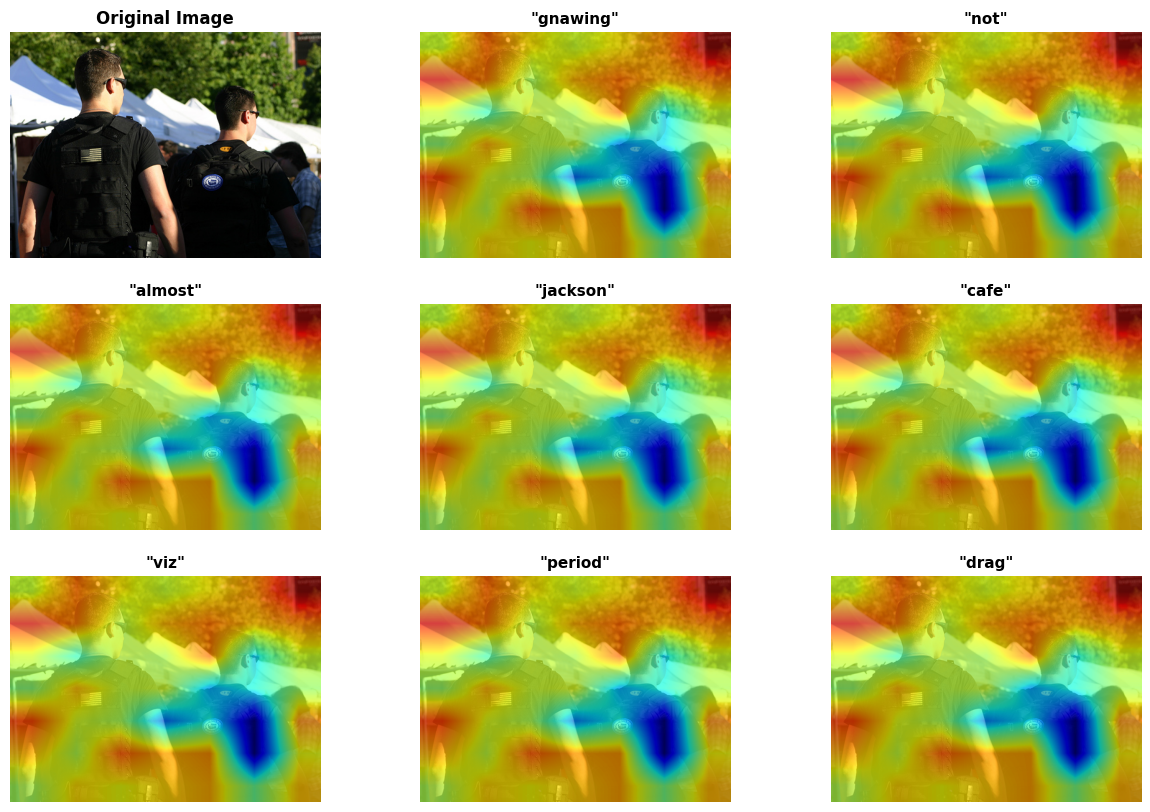

In [ ]:
visualize_multiple_images(IMAGES_DIR, dataset, encoder, decoder, vocab, num_images=5)